<span style="font-family: 'Times New Roman', Times, serif; line-height: 1.2;">

# 05 - Content-Based Music Recommendation System

This notebook implements a content-based recommender system using cosine similarity over audio features. The system operates on tracks that appear in both the Million Playlist Dataset and have complete feature data, creating a universe of approximately 514,000 tracks.

## 1. Setup and Data Loading

Loading track metadata and the normalized feature matrix for the recommendation universe.

</span>

In [ ]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

from src.features import load_feature_matrix

from src.recommender_helpers import (
    describe_tracks,
    most_similar_tracks,
    find_track_ids_by_name,
    evaluate_cosine_on_playlists,
    recommend_by_name_with_differences,
    plot_similarity_distribution,
    plot_pca_recommendations
)

PROJECT_ROOT: C:\Users\Kiera\Music_Recommender


In [15]:
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

track_meta_path = DATA_PROCESSED / "track_metadata.csv"
meta_df = pd.read_csv(track_meta_path)

meta_df["track_id"] = meta_df["track_id"].astype(str)

print("track_metadata.csv shape:", meta_df.shape)
meta_df.head()


track_metadata.csv shape: (679889, 7)


,track_id,track_name,artist_name,album_name,artist_uri,album_uri,duration_ms
0,0000uJA4xCdxThagdLkkLR,Heart As Cold As Stone,Cherryholmes,Cherryholmes,spotify:artist:5kEVfWQGTw0rIDO2Jqq1ww,spotify:album:3SPMBGMEvPw21lmT5b1ApW,161186
1,00039MgrmLoIzSpuYKurn9,Thas What I Do,Zach Farlow,The Great Escape 2,spotify:artist:2jTojc4rAsOMx6200a8Ah1,spotify:album:0UHfgx3ITlxePDXLaN5Y6x,222727
2,0005w1bMJ7QAMl6DY98oxa,"Sonata in G Major, BuxWV 271: Allegro -",Dietrich Buxtehude,"Chamber Music: London Baroque - Rosenmuller, J...",spotify:artist:2YfFYZnshSzgfLsKZMM4VL,spotify:album:6oRWciCAwKegipcCc5FlWe,111573
3,0007AYhg2UQbEm88mxu7js,Mandarin Oranges Part 2,Little Simz,E.D.G.E,spotify:artist:6eXZu6O7nAUA5z6vLV8NKI,spotify:album:32RJzqlapfiU0fr2l4SSW9,198000
4,000CTwOSsvRs0bgXlwB64e,Shady World,Celly Cel,The Lost Tapes,spotify:artist:6k7TX5dxiKZiwMWTn8ZKbl,spotify:album:6LOmO9x8uPwlc3gSXZqqi8,155238


In [ ]:
# Set of track_ids that have metadata (MPD universe)
meta_id_set = set(meta_df["track_id"])

# Load feature matrix ONLY for these track_ids
X_norm, track_ids, track_id_to_idx, feat_df = load_feature_matrix(
    allowed_track_ids=meta_id_set
)

print("Feature matrix shape (n_tracks, n_features):", X_norm.shape)
print("Number of unique track_ids in feature matrix:", len(track_ids))

row_norms = np.linalg.norm(X_norm, axis=1)
print("Mean row L2 norm:", row_norms.mean())
print("Std of row L2 norm:", row_norms.std())


Feature matrix shape (n_tracks, n_features): (514672, 13)
Number of unique track_ids in feature matrix: 514672
Mean row L2 norm: 1.0
Std of row L2 norm: 4.6481937e-08


In [17]:
feature_id_set = set(track_ids)

meta_df_filtered = meta_df[meta_df["track_id"].isin(feature_id_set)].copy()

print("Tracks in feature matrix:", len(feature_id_set))
print("Tracks with metadata:   ", len(meta_df))
print("Overlap (features ∩ meta):", len(meta_df_filtered))

meta_df_filtered.head()


Tracks in feature matrix: 514672
Tracks with metadata:    679889
Overlap (features ∩ meta): 514672


,track_id,track_name,artist_name,album_name,artist_uri,album_uri,duration_ms
0,0000uJA4xCdxThagdLkkLR,Heart As Cold As Stone,Cherryholmes,Cherryholmes,spotify:artist:5kEVfWQGTw0rIDO2Jqq1ww,spotify:album:3SPMBGMEvPw21lmT5b1ApW,161186
1,00039MgrmLoIzSpuYKurn9,Thas What I Do,Zach Farlow,The Great Escape 2,spotify:artist:2jTojc4rAsOMx6200a8Ah1,spotify:album:0UHfgx3ITlxePDXLaN5Y6x,222727
2,0005w1bMJ7QAMl6DY98oxa,"Sonata in G Major, BuxWV 271: Allegro -",Dietrich Buxtehude,"Chamber Music: London Baroque - Rosenmuller, J...",spotify:artist:2YfFYZnshSzgfLsKZMM4VL,spotify:album:6oRWciCAwKegipcCc5FlWe,111573
5,000JBgYWfJQqdFaRqu2n3f,Li'l Darlin',Joe Pass,Portrait,spotify:artist:4DuZTASH5eSyd0K73W6fuZ,spotify:album:2zm8AkHjOhwdvnj8NSVg6g,227626
6,000JCyEkMFumqCZQJAORiQ,California Water,Nipsey Hussle,Enough Is Enough,spotify:artist:0EeQBlQJFiAfJeVN2vT9s0,spotify:album:4pfWrpnLFM1jHiw3foRpKK,207124


<span style="font-family: 'Times New Roman', Times, serif; line-height: 1.2;">

### 1.1 Data Validation and Overlap

Verifying the overlap between tracks with features and tracks with metadata.

</span>

In [ ]:
np.random.seed(0)
random_idxs = np.random.choice(len(track_ids), size=5, replace=False)
describe_tracks(track_ids[random_idxs])


,track_id,track_name,artist_name,album_name,artist_uri,album_uri,duration_ms
0,2guo3CprPmlO7YN18AHY8l,"Prélude et fugue 2 en ut majeur, Bw 847 (1er l...",Johann Sebastian Bach,Bach : Le clavier bien tempéré,spotify:artist:5aIqB5nVVvmFsvSdExz408,spotify:album:6eD9PrgXHms0RtB2d5MNfH,184884
1,5wzUTd5rsxCc1Dt0C9a27B,The Whale Song,Modest Mouse,"No One's First, And You're Next",spotify:artist:1yAwtBaoHLEDWAnWR87hBT,spotify:album:4YvdAtWh6LlnIrv0qIqkCF,364733
2,0Oss98zJQb1DPCHXP7DLFv,The Neighborhood Is Bleeding,Manchester Orchestra,I'm Like A Virgin Losing A Child,spotify:artist:5wFXmYsg3KFJ8BDsQudJ4f,spotify:album:7criqG4fAIy0N0TdRpL2SA,168826
3,097rKjclHIS3Bhq2kvisT5,Diet Coke Slutz,Knowmads,Knowmads,spotify:artist:6aUKy2LG1OU6KhYOZADolN,spotify:album:3wzgOT3wNoYEUPUgx0WTjB,250228
4,4C7BIBovuWAhOtSfTkJxrS,I'm a Nut,Caspar Babypants,More Please!,spotify:artist:4wwj0BGZ6T61LB1jBWdo0n,spotify:album:4IjjmD5S292op49x0kc677,176360


<span style="font-family: 'Times New Roman', Times, serif; line-height: 1.2;">

## 2. Core Recommendation Functions

Implementing cosine similarity-based track recommendations using the normalized feature space.

</span>

<span style="font-family: 'Times New Roman', Times, serif; line-height: 1.2;">

### 2.1 Track Search Utility

Helper function for finding tracks by name to identify seed tracks for recommendations.

</span>

In [ ]:
find_track_ids_by_name("Toxic", max_results=10)


,track_id,track_name,artist_name,album_name
140,007ZSFFUMZD0rVCuxO5WHK,Intoxicated,Joomanji,BamaLoveSoul presents On Deck 2
20940,0EkB09i9ohIUnsw45jzEyf,Toxic,Yael Naim,Yael Naim
21720,0FHdsktY5TApHrZLD3scIs,Intoxicated,Now And On Earth,Blacked Out
23674,0GgLVyWNBhHPl6sboaw3l9,Intoxicated,Hinder,When The Smoke Clears
33201,0NNTDgJ0DUgMo97Y4QTJcO,Necrotoxic,Carnifex,Slow Death
48246,0Y5tjLcIvmGxg3fHIXLqyA,Toxic,My Enemies & I,Sick World
61574,0hcS7u5JNePMz53l77FyVd,Toxic Is Dead - Video Edit,The Toxic Avenger,Scion Sampler Vol. 26: The Toxic Avenger
61871,0hpeQ6d58mOycZa6GGEZdS,Toxic (Battements Tendus 1),Andrew Holdsworth,"Reimagined for Ballet Class (Pop), Vol. 1"
65716,0keA5kJmiFFypmbcl0Iq4M,Intoxicated,Groovecatcher,After The Rain
69242,0n8EJNX6HmAMbnSkOqGWEH,Intoxicated - Bonus Track,Obituary,Inked in Blood (Deluxe Version)


<span style="font-family: 'Times New Roman', Times, serif; line-height: 1.2;">

## 3. Recommendation Examples

Demonstrating the recommendation system with different seed tracks.

### 3.1 Random Seed Track

</span>

In [ ]:
np.random.seed(42)
seed_track_id = meta_df_filtered["track_id"].sample(1).iloc[0]

seed_row = meta_df_filtered[meta_df_filtered["track_id"] == seed_track_id]
print("Seed track:")
seed_row[["track_name", "artist_name", "album_name", "track_id"]]


6g9KOSbMv76BzRmsL5eoRo
Seed track:


,track_name,artist_name,album_name,track_id
582896,There's No Sky,Jaill,There's No Sky (Oh My My),6g9KOSbMv76BzRmsL5eoRo


In [22]:
recs = most_similar_tracks(seed_track_id, top_k=15)

print("Recommendations:")
recs[["track_name", "artist_name", "album_name", "similarity"]]


Recommendations:


,track_name,artist_name,album_name,similarity
0,Lose The Lazy (Tobiahs Remix),Airwolf,Lose The Lazy featuring Stahsi,0.964232
1,Fallin',Outdream,Fallin',0.962722
2,In The Dark - Proper Villains Remix,DEV,In The Dark,0.959648
3,Hold Your Breath - Original Mix,Kezwik,Problematic / Hold Your Breath,0.954501
4,More Than You,Koven,More Than You,0.950022
5,Love & Lies - Single Version,DVBBS,Love & Lies,0.949375
6,optimistic,Worm is Green,Push play,0.948729
7,Come Undone,Placebo,Battle For The Sun,0.946738
8,Mirror’s Image,The Horrors,Primary Colours,0.944140
9,Into The Past,NERO,Music From Baz Luhrmann's Film The Great Gatsby,0.942537


<span style="font-family: 'Times New Roman', Times, serif; line-height: 1.2;">

### 3.2 Specific Artist Example

Testing recommendations with a known track: "Ivy" by Frank Ocean.

</span>

In [ ]:
seed_track_id = '2ZWlPOoWh0626oTaHrnl2a'

seed_row = meta_df_filtered[meta_df_filtered["track_id"] == seed_track_id]
print("Seed track:")
seed_row[["track_name", "artist_name", "album_name", "track_id"]]

Seed track:


,track_name,artist_name,album_name,track_id
224894,Ivy,Frank Ocean,Blonde,2ZWlPOoWh0626oTaHrnl2a


In [ ]:
recs = most_similar_tracks(seed_track_id, top_k=15)

print("Recommendations:")
recs[["track_name", "artist_name", "album_name", "similarity"]]

Recommendations:


,track_name,artist_name,album_name,similarity
0,I Hadn't Anyone Till You (feat. Michael Hashim),Boilermaker Jazz Band,Nice Work If You Can Get It,0.968663
1,Chalk,Blanco White,The Wind Rose EP,0.962264
2,So Down - alternative version,Sean Hayes,Outtakes & Alternatives,0.962063
3,Califormula,blackbear,The Afterglow,0.961590
4,Buffalo Skinners,John Lowell,I Am Going to the West,0.959955
5,Don't Be A Fool,Gregory Porter,Take Me To The Alley,0.958863
6,Last Kind Words,Rhiannon Giddens,Tomorrow Is My Turn,0.957232
7,Sem Fantasia,Chico Buarque,Chico Buarque de Hollanda Vol. 3,0.956958
8,Indestructible - Acoustic Version,Robyn,Body Talk pt.2,0.955616
9,All I Need,Xscape,Traces Of My Lipstick,0.955566


<span style="font-family: 'Times New Roman', Times, serif; line-height: 1.2;">

## 4. Similarity Distribution Analysis

Examining the distribution of cosine similarities across the entire catalog for a given seed track.

</span>

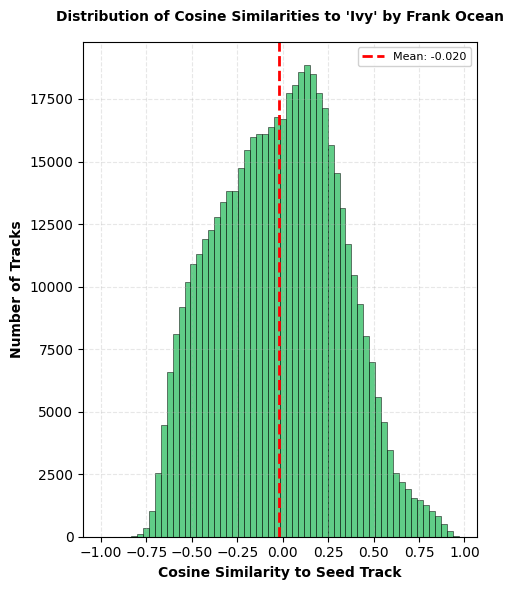

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

q_idx = track_id_to_idx[seed_track_id]
q_vec = X_norm[q_idx]
sims_all = X_norm @ q_vec

sims_all[q_idx] = -1.0

plt.figure(figsize=(5, 6))
plt.hist(sims_all, bins=60, color='#1DB954', alpha=0.7, edgecolor='black', linewidth=0.5)

mean_sim = np.mean(sims_all[sims_all > -1])
plt.axvline(mean_sim, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_sim:.3f}')


plt.xlabel("Cosine Similarity to Seed Track", fontsize=10, fontweight='bold')
plt.ylabel("Number of Tracks", fontsize=10, fontweight='bold')
plt.title("Distribution of Cosine Similarities to 'Ivy' by Frank Ocean", 
          fontsize=10, fontweight='bold', pad=15)
plt.legend(fontsize=8, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

<span style="font-family: 'Times New Roman', Times, serif; line-height: 1.2;">

## 5. Feature Space Visualization

Using PCA to project the high-dimensional feature space into 2D for visual analysis of recommendation quality.

</span>

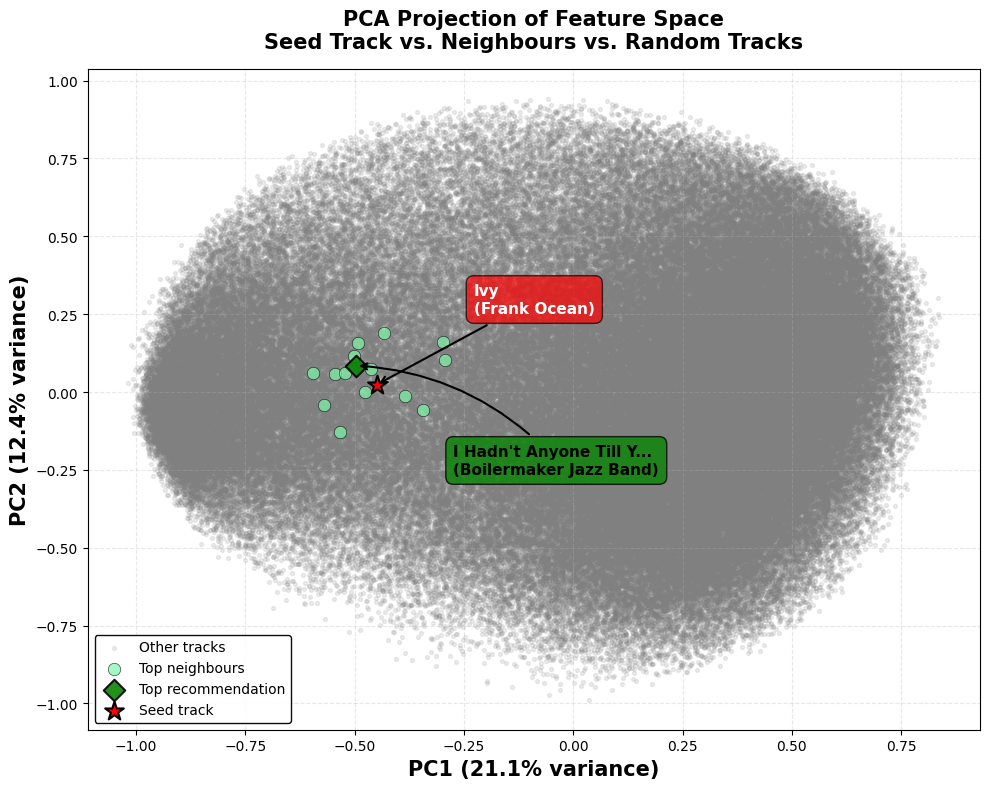

In [ ]:
from sklearn.decomposition import PCA

np.random.seed(123)

n_background = 200000
all_indices = np.arange(len(track_ids))

bg_indices = np.random.choice(all_indices, size=min(n_background, len(all_indices)), replace=False)

top_k = 15
top_recs = most_similar_tracks(seed_track_id, top_k=top_k)
top_indices = np.array([track_id_to_idx[tid] for tid in top_recs["track_id"]])

indices_to_plot = np.unique(np.concatenate([[q_idx], top_indices, bg_indices]))
X_subset = X_norm[indices_to_plot]

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_subset)

global_to_2d_idx = {g: i for i, g in enumerate(indices_to_plot)}

seed_2d = X_2d[global_to_2d_idx[q_idx]]
top_2d = X_2d[[global_to_2d_idx[i] for i in top_indices]]
bg_2d = X_2d[[global_to_2d_idx[i] for i in bg_indices if i in global_to_2d_idx]]

# Get the top recommendation for labeling
top_rec_idx = top_indices[0]
top_rec_2d = X_2d[global_to_2d_idx[top_rec_idx]]

# Get track names for labels
seed_name = meta_df_filtered[meta_df_filtered["track_id"] == seed_track_id]["track_name"].values[0]
seed_artist = meta_df_filtered[meta_df_filtered["track_id"] == seed_track_id]["artist_name"].values[0]
top_rec_name = top_recs.iloc[0]["track_name"]
top_rec_artist = top_recs.iloc[0]["artist_name"]

fig, ax = plt.subplots(figsize=(10, 8))

# Background cloud
ax.scatter(bg_2d[:, 0], bg_2d[:, 1], s=8, alpha=0.15, c='gray', label="Other tracks")

# Neighbours
ax.scatter(top_2d[1:, 0], top_2d[1:, 1], s=80, alpha=0.7, c="#7EF7A8", 
            edgecolors='black', linewidth=0.5, label="Top neighbours", zorder=3)

# Top recommendation
ax.scatter(top_rec_2d[0], top_rec_2d[1], s=120, alpha=0.9, c="#078502", 
            edgecolors='black', linewidth=1.5, label="Top recommendation", zorder=4, marker='D')

# Seed track
ax.scatter(seed_2d[0], seed_2d[1], s=200, marker="*", c="#FF0000", 
            edgecolors='black', linewidth=1.5, label="Seed track", zorder=5)

x_range = bg_2d[:, 0].max() - bg_2d[:, 0].min()
y_range = bg_2d[:, 1].max() - bg_2d[:, 1].min()
offset_x = x_range * 0.12 
offset_y = y_range * 0.12  


ax.annotate(f"{seed_name}\n({seed_artist})", 
             xy=(seed_2d[0], seed_2d[1]),
             xytext=(seed_2d[0] + offset_x, seed_2d[1] + offset_y),
             bbox=dict(boxstyle="round,pad=0.5", facecolor='red', alpha=0.7, edgecolor='black'),
             fontsize=11, fontweight='bold', color='white',
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=1.5),
             zorder=6)

top_rec_display = top_rec_name if len(top_rec_name) <= 25 else top_rec_name[:22] + "..."
ax.annotate(f"{top_rec_display}\n({top_rec_artist})", 
             xy=(top_rec_2d[0], top_rec_2d[1]),
             xytext=(top_rec_2d[0] + offset_x, top_rec_2d[1] - offset_y*1.5),
             bbox=dict(boxstyle="round,pad=0.5", facecolor='#078502', alpha=0.8, edgecolor='black'),
             fontsize=11, fontweight='bold',
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2', lw=1.5),
             zorder=6)

ax.legend(loc='best', fontsize=10, framealpha=0.95, edgecolor='black')
ax.set_title("PCA Projection of Feature Space\nSeed Track vs. Neighbours vs. Random Tracks", 
          fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", 
           fontsize=15, fontweight='bold')
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)", 
           fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [ ]:
interactions_path = DATA_PROCESSED / "interactions.parquet"
interactions = pd.read_parquet(interactions_path)

interactions["track_id"] = interactions["track_id"].astype(str)

feature_id_set = set(track_ids)
interactions = interactions[interactions["track_id"].isin(feature_id_set)].copy()

print("Interactions shape after filtering to feature-space tracks:", interactions.shape)
interactions.head()


Interactions shape after filtering to feature-space tracks: (6175813, 4)


,pid,track_id,pos,duration_ms
0,0,0UaMYEvWZi0ZqiDOoHU3YI,0,226863
1,0,6I9VzXrHxO9rA9A5euc8Ak,1,198800
2,0,0WqIKmW4BTrj3eJFmnCKMv,2,235933
3,0,1AWQoqb9bSvzTjaLralEkT,3,267266
4,0,1lzr43nnXAijIGYnCT8M8H,4,227600


<span style="font-family: 'Times New Roman', Times, serif; line-height: 1.2;">

## 6. Offline Evaluation

Evaluating recommendation quality using held-out playlist data from the MPD. Computing recall@K and hit rate to quantify recommendation performance.

</span>

In [ ]:
avg_recall_10, avg_hit_10, n_eval = evaluate_cosine_on_playlists(num_playlists=500, top_k=10, seed=42)
print(f"Evaluated on {n_eval} playlists.")
print(f"Average Recall@10:  {avg_recall_10:.4f}")
print(f"Average HitRate@10: {avg_hit_10:.4f}")

Evaluated on 500 playlists.
Average Recall@10:  0.0004
Average HitRate@10: 0.0120


<span style="font-family: 'Times New Roman', Times, serif; line-height: 1.2;">

## 7. Feature-Level Analysis

Analyzing which audio features contribute most to differences between seed tracks and recommendations.

</span>

In [ ]:
feature_cols = [c for c in feat_df.columns if c != "track_id"]
print("Feature columns used for differences:", feature_cols)

feature_stats = feat_df[feature_cols].agg(["mean", "std"])
feat_means = feature_stats.loc["mean"]
feat_stds = feature_stats.loc["std"].replace(0, 1.0)

feature_stats


Feature columns used for differences: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature', 'key', 'mode']


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,key,mode
mean,0.557650,0.607277,-8.880156,0.088019,0.317553,0.171066,0.207499,0.474457,120.566945,242338.721075,3.896175,5.259620,0.658693
std,0.179049,0.254951,5.129729,0.106231,0.336128,0.316723,0.186417,0.262085,29.735955,124007.575767,0.433795,3.563163,0.474149


<span style="font-family: 'Times New Roman', Times, serif; line-height: 1.2;">

### 7.1 Recommendation with Feature Differences

Enhanced recommendation function that identifies the most different audio feature for each recommendation.

</span>

In [ ]:
recs = recommend_by_name_with_differences("pass out", candidate_index=2, top_k=15)

Search results:


,track_id,track_name,artist_name,album_name
0,1JgWCIOPxGl7IvlIkqO4Oq,Pass Out,Ludacris,The Red Light District
1,1ZPjHKNfc0H83gZDoGFjya,Pass out (Original Version),Chrishan,The Ultimate Collection
2,2cY7WSxFIsZQaoDNJe7Fz3,Pass Out,Tinie Tempah,Disc-Overy
3,47aEKbvbgAD3cPoorJQzj1,Pass Out,Chris Brown,Graffiti
4,6M2SAwhhWxPZ6lekYwj8dK,Until I Pass Out,Uncle Reece,Until I Pass Out
5,6zh56VneNv8XcYzv32hCkx,Party Pass Out,Taylor Gang,"TGOD, Vol. 1"



Chosen seed track:


track_name                   Pass Out
artist_name              Tinie Tempah
album_name                 Disc-Overy
track_id       2cY7WSxFIsZQaoDNJe7Fz3
Name: 229227, dtype: object


Seed track audio features (available columns):


,track_id,track_name,artist_name,album_name,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,key,mode
2cY7WSxFIsZQaoDNJe7Fz3,2cY7WSxFIsZQaoDNJe7Fz3,Pass Out,Tinie Tempah,Disc-Overy,0.693,0.891,-3.261,0.296,0.0281,0.0,0.143,0.532,91.1,4.0,1.0,1.0



Recommendations with audio features and most different feature (normalised):


,track_name,artist_name,album_name,similarity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,key,mode,most_diff_feature,most_diff_abs_zdiff
0,Monotony,Afu-Ra,Body Of The Life Force,0.987014,0.689,0.949,-3.194,0.350,0.09260,0.000000,0.1040,0.501,92.350,4.0,1,1,speechiness,0.508326
1,Jeff N Fess feat. Rhymefest,DJ Jazzy Jeff,The Return Of The Magnificent,0.985707,0.663,0.930,-4.645,0.328,0.06210,0.000000,0.1550,0.620,91.899,4.0,1,1,valence,0.335769
2,Swords Drawn,Army Of The Pharaohs,Jedi Mind Tricks presents The Best of Army of ...,0.984474,0.688,0.898,-3.704,0.320,0.00870,0.000000,0.0919,0.578,101.993,4.0,0,1,tempo,0.366324
3,Represent,Nas,Illmatic XX,0.981965,0.702,0.832,-4.964,0.318,0.02000,0.000003,0.1890,0.619,92.362,4.0,1,1,loudness,0.331986
4,Uh Oh,Talib Kweli,Gutter Rainbows,0.981329,0.620,0.848,-4.234,0.290,0.00531,0.000029,0.1720,0.531,82.710,4.0,2,1,danceability,0.407710
5,Sets Go Up (feat. Wacko) - feat. Wacko Explici...,Juvenile,Reality Check,0.980260,0.689,0.925,-4.658,0.248,0.10200,0.000022,0.0862,0.552,98.192,4.0,1,1,speechiness,0.451845
6,Kocky,Tech N9ne Collabos,Welcome to Strangeland,0.979936,0.690,0.858,-3.688,0.285,0.15100,0.000000,0.1120,0.601,78.976,4.0,1,1,tempo,0.407722
7,Daddy Fat Sax,Big Boi,Sir Lucious Left Foot...The Son Of Chico Dusty,0.979866,0.668,0.894,-3.376,0.325,0.01500,0.000000,0.1150,0.629,94.591,4.0,2,1,valence,0.370109
8,Floating to Nowhere,Lando Chill,"For Mark, Your Son",0.979470,0.734,0.839,-4.999,0.265,0.08430,0.000000,0.1870,0.566,86.936,4.0,1,1,loudness,0.338809
9,LA,Nelly,Brass Knuckles,0.979366,0.634,0.782,-4.693,0.274,0.04400,0.000000,0.1720,0.551,83.305,4.0,1,1,energy,0.427532
